In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class Bandit:
  """Bandit class, given n, models a n-armed bandit

      n - number of arms
  """

  def __init__(self, n):
    """Initialise bandit, assigning n and generating a Q* value from normal distribution N(0,1)
    Define the optimal action as the action with the highest Q* value.
    """
    self.n = n
    self.q_true = np.random.normal(0, 1, n)
    self.optimal_action = np.argmax(self.q_true)

  def step(self, action):
    """Computes reward for a given step, given an action from the agent"""
    reward = np.random.normal(self.q_true[action], 1)
    return reward

In [3]:
class Agent:
  """Agent class:

            n - number of arms of the bandit the agent will be playing
      epsilon - exploration rate (Probability of exploration)
  """
  def __init__(self, n, epsilon):
    """Initialises agent, defining n and epsilon"""
    self.n = n
    self.epsilon = epsilon

  def reset(self):
    """Resets the vectors storing our estimated q values, count for each time an arm was played
    and count of total actions"""
    self.q_estimates = np.zeros(self.n)
    self.n_estimates = np.zeros(self.n)
    self.total_actions = 0

  def choose_action(self):
    """This function represents the agents decision making process, with probability 1 - epsilon,
    choose current estimated optimal value, else explore other options (i.e. act randomly)"""
    if np.random.random() < self.epsilon:
      return np.random.randint(self.n)
    else:
      return np.argmax(self.q_estimates)

  def update_estimates(self, action, reward):
    """After acting, update our estimated q value based on the reward we obtained"""
    self.n_estimates[action] += 1
    self.q_estimates[action] += (reward - self.q_estimates[action]) / self.n_estimates[action]
    self.total_actions += 1


In [4]:
def run_simulation(n, runs=2000, steps=2000, epsilons=[0, 0.01, 0.1]):
  """Function to run our experiment:
          n - number of arms
       runs - number of times we run our experiment
      steps - number of plays per experiment
   epsilons - list of epsilon values to test
  """
  #Dictionaries to store the mean rewards, percent of actions that were optimal (i.e. arm with highest true q chosen),
  #and our agents
  mean_rewards = {}
  percentage_optimal_action = {}
  agents = {}

  #Create a vector to store the mean rewards, percent of actions that were optimal for each epsilon we are testing
  for epsilon in epsilons:
    mean_rewards[f"ε = {epsilon}"] = np.zeros(steps)
    percentage_optimal_action[f"ε = {epsilon}"] = np.zeros(steps)



  for run in range(runs):
    #Generate new bandit for each run
    bandit = Bandit(n)

    for epsilon in epsilons:
      #Reset agents for each run
      agents[f"ε = {epsilon}"] = Agent(n, epsilon)
      agents[f"ε = {epsilon}"].reset()

    for step in range(steps):
      for agent_name, agent in agents.items():
        #For each step choose action, obtain reward, update estimates and store mean reward
        action = agent.choose_action()
        reward = bandit.step(action)
        agent.update_estimates(action, reward)
        mean_rewards[agent_name][step] += reward

        if action == bandit.optimal_action:
          #If optimal action is selected add one to total
          percentage_optimal_action[agent_name][step] += 1

  for agent_name in mean_rewards:
    #Calculate evaluation metrics
    mean_rewards[agent_name] /= runs
    percentage_optimal_action[agent_name] /= runs/100

  return mean_rewards, percentage_optimal_action

In [5]:
def plot_results(mean_rewards, percentage_optimal_action, n):
  """Function to plot our results
                 mean_rewards - mean rewards for each agent
    percentage_optimal_action - percentage of actions that were optimal for each agent
                            n - number of arms
  """
  sns.set()
  fig, axs = plt.subplots(1, 1, figsize=(12, 6))
  #Plot mean rewards
  for agent_name, mean_reward in mean_rewards.items():
    axs.plot(mean_reward, label=agent_name)
  axs.legend()
  axs.set_title(f"Average reward for n = {n}")
  axs.set_xlabel("Steps")
  axs.set_ylabel("Mean reward")
  plt.tight_layout()
  plt.show()
  fig1, axs1 = plt.subplots(1, 1, figsize=(12, 6))

  #Plot optimal action selection percentage
  for agent_name, percent_oa in percentage_optimal_action.items():
    axs1.plot(percent_oa, label=agent_name)
  axs1.legend()
  axs1.set_title(f"Percentage of optimal action for n = {n}")
  axs1.set_xlabel("Steps")
  axs1.set_ylabel("%Optimal action")
  plt.tight_layout()
  plt.show()

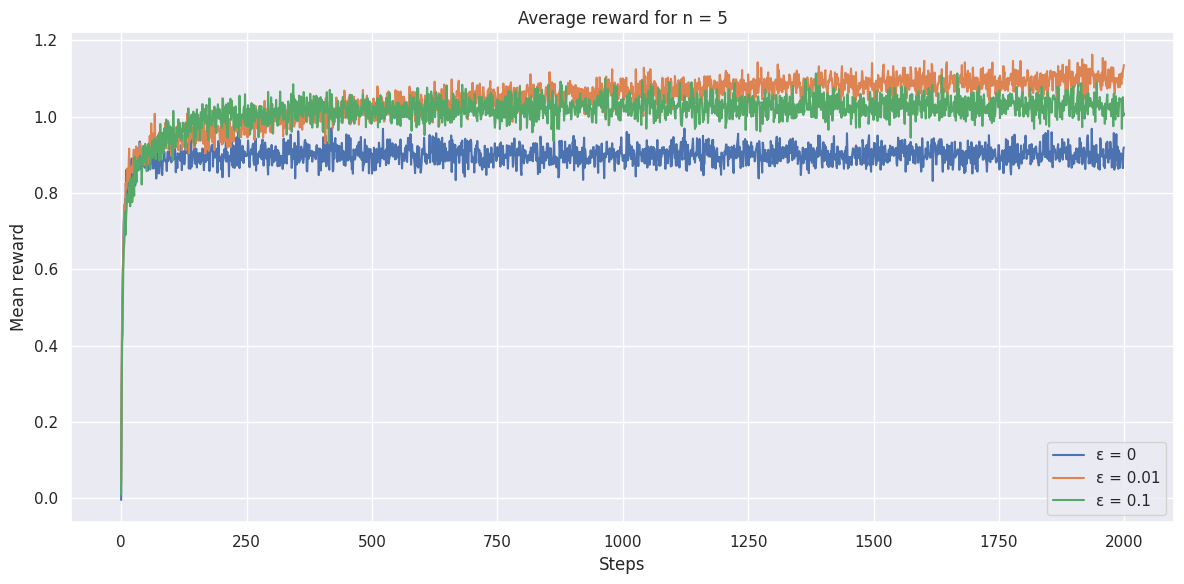

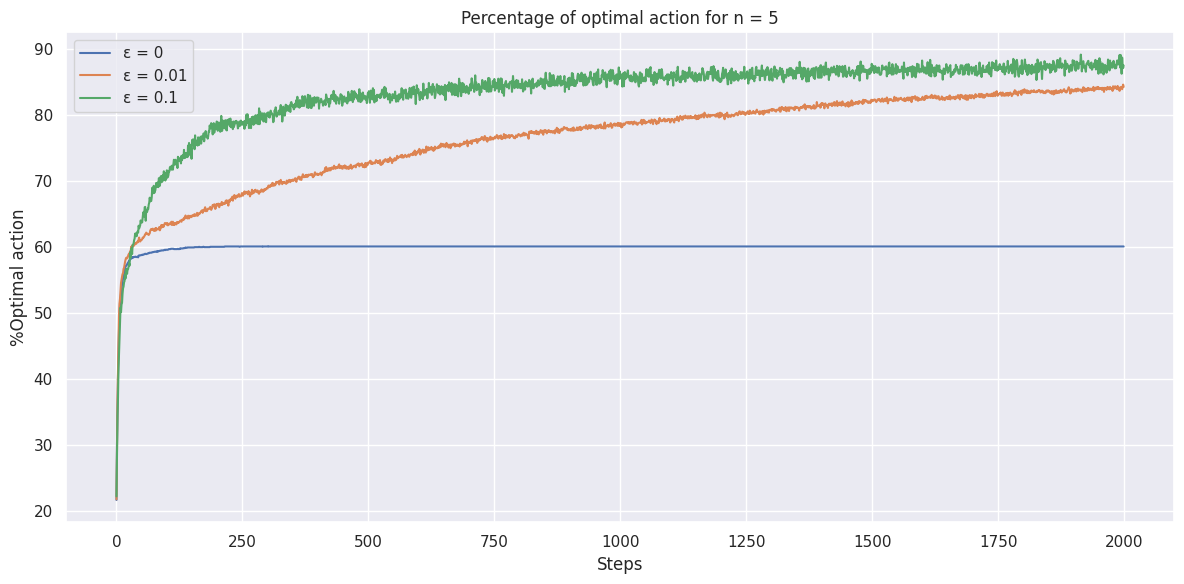

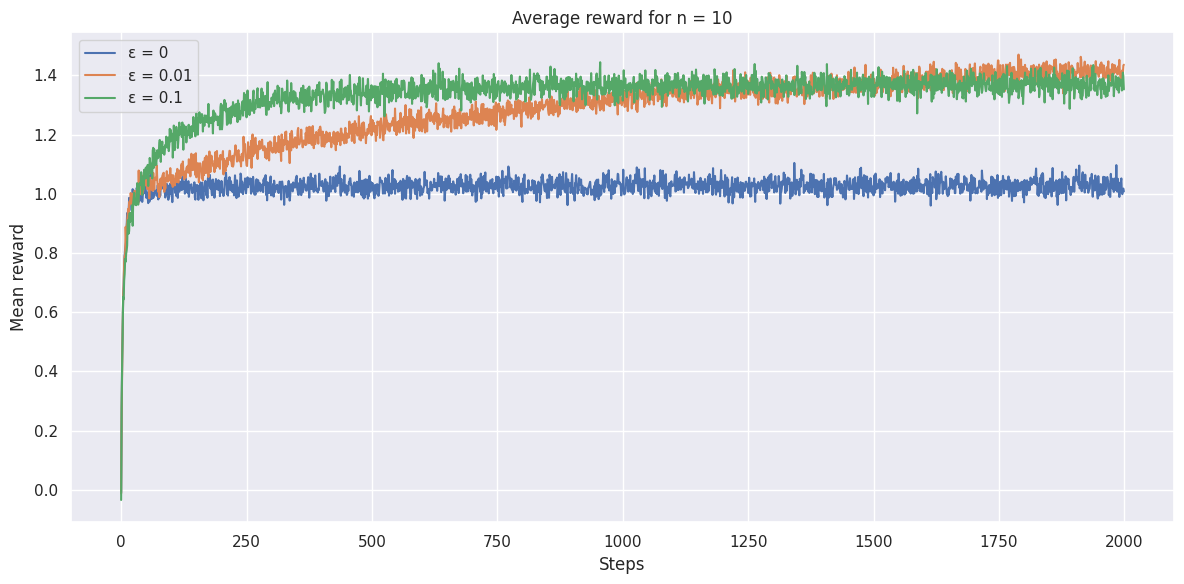

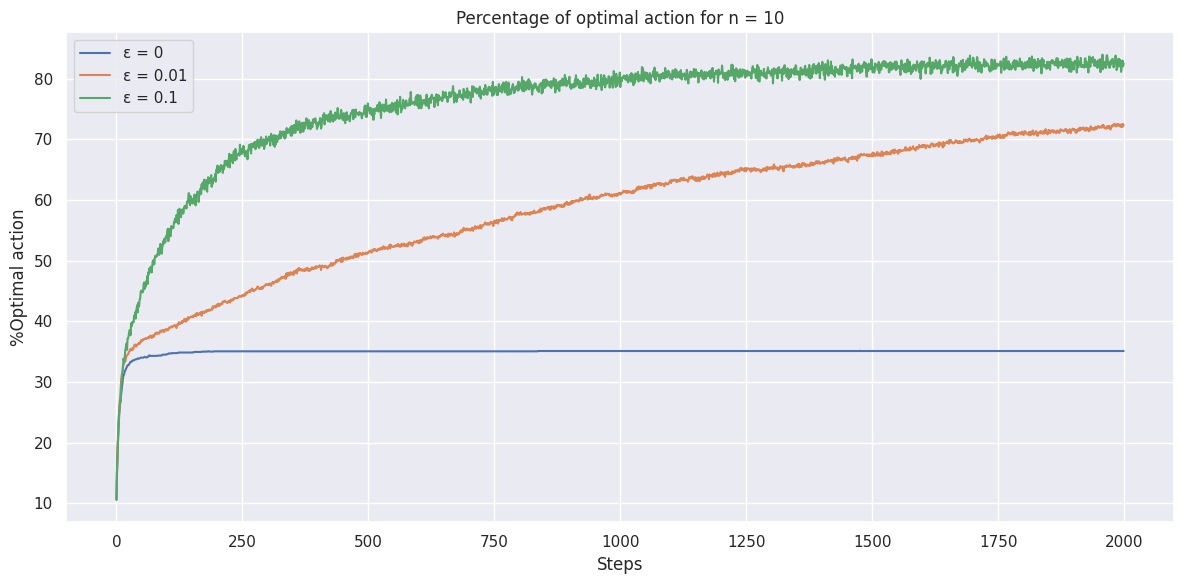

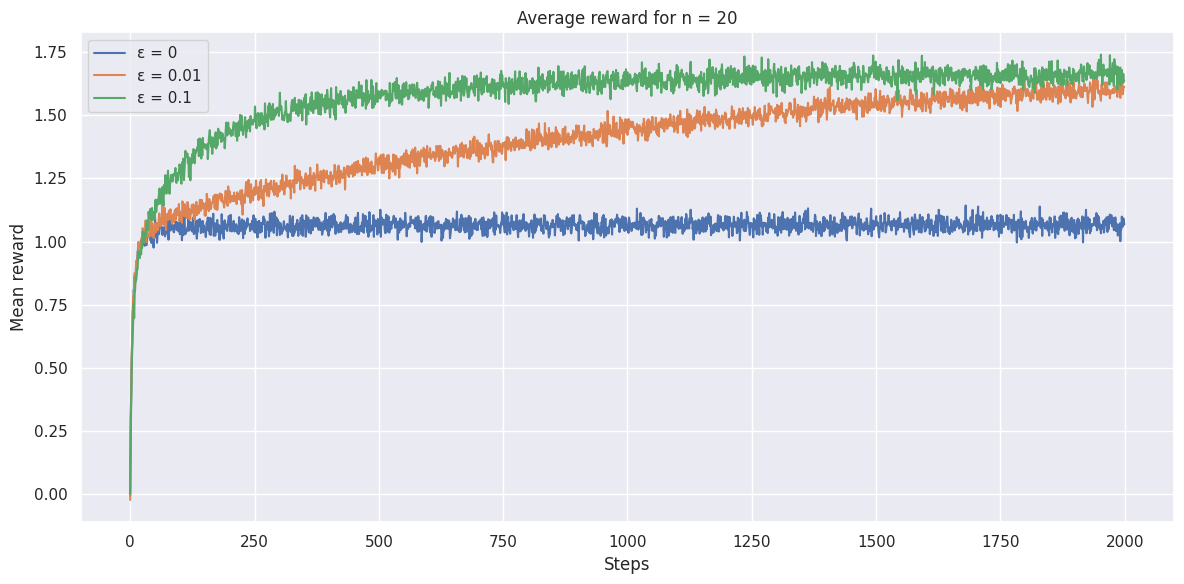

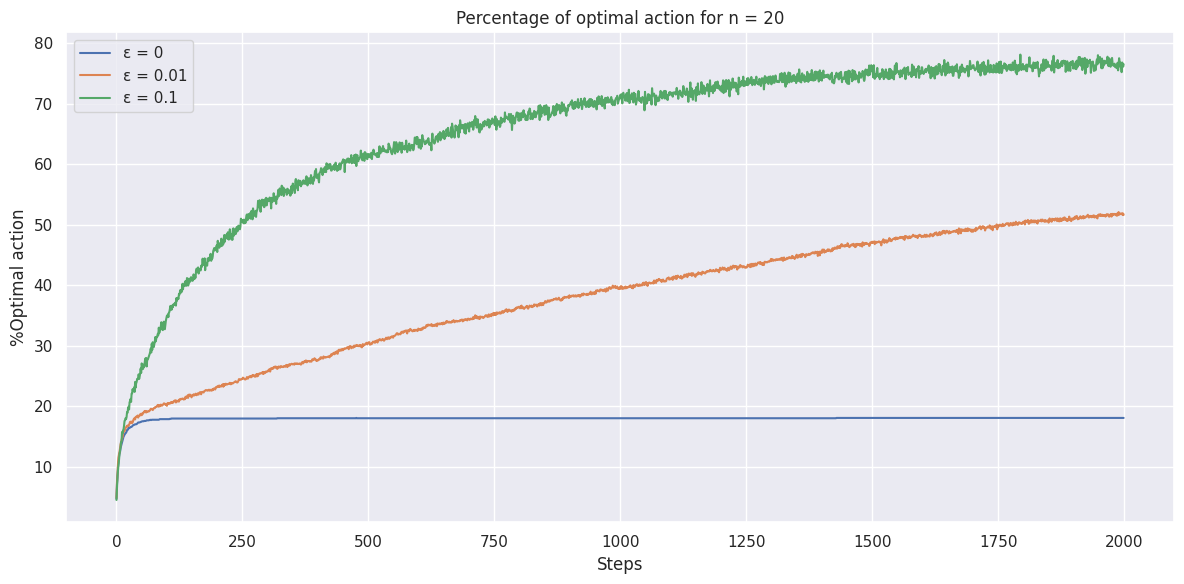

In [6]:
#Run experiment
ns = [5, 10, 20]
epsilons = [0, 0.01, 0.1]
for n in ns:
  mean_rewards, percentage_optimal_action = run_simulation(n, runs=2000, steps=2000, epsilons=[0, 0.01, 0.1])
  plot_results(mean_rewards, percentage_optimal_action, n)